In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/test_vienna60_annotated.csv")

# Basic cleanup
df = df.dropna(subset=["kl_60", "predicted_MFE"]).copy()
df["kl_60"] = pd.to_numeric(df["kl_60"], errors="coerce")
df["predicted_MFE"] = pd.to_numeric(df["predicted_MFE"], errors="coerce")
df = df.dropna(subset=["kl_60", "predicted_MFE"])

df.head()

,exon,num_DNA_reads,num_exon_inclusion,num_exon_skipping,num_intron_retention,num_splicing_in_exon,num_bad_exon1,num_bad_reads,num_unknown_splicing,total_noncanonical,...,st_predicted_prob,predicted_secondary_struct,predicted_MFE,model_sequence,wobble_count,flanks_added,predicted_PSI_60,kl_60,freq_MFE,ensemble_diversity
0,CTCACGTCCAACCCCGGCCGAAGTGGTGTTAGGCCGCAAATTGTAC...,13,83,158,0,0,3,1,10,14,...,0.162405,.........................((((((.(((((((.....((...,-10.32,CATCCAGGTTCTCACGTCCAACCCCGGCCGAAGTGGTGTTAGGCCG...,4,True,0.639778,0.179302,0.020607,10.11
1,CCCTCCTTAACCTCCAAGTGCTTTACTGGCGCTGCCTACAATTCCA...,16,56,15,0,0,0,0,4,4,...,0.155897,...((..((((...............((((((.....))))))......,-6.42,CATCCAGGTTCCCTCCTTAACCTCCAAGTGCTTTACTGGCGCTGCC...,6,True,0.707430,0.017021,0.008963,18.10
2,ACACTCCGCAGCACACTCGGCAAAGAAGTTAGGCCCCGCTCTTACA...,6,0,143,0,0,1,0,3,4,...,0.051171,.....................................((((((((....,-4.64,CATCCAGGTTACACTCCGCAGCACACTCGGCAAAGAAGTTAGGCCC...,8,True,0.007627,0.007647,0.017081,12.23
3,ACCCACAAAACGCAATTTACACCCAATACCACAGGGGGCGAACATA...,25,9,373,0,0,1,0,14,15,...,0.065669,..(((((.............(((........(((..........))...,-2.85,CATCCAGGTTACCCACAAAACGCAATTTACACCCAATACCACAGGG...,2,True,0.025151,0.000053,0.021267,18.61
4,GGTAGTACGCCAATTCGCCGGTGCCGCGAGCCAGAGGCTACCAAAA...,37,328,6,0,2,2,1,11,14,...,0.214096,....((((((((((((.......(((((.......))))).........,-9.94,CATCCAGGTTGGTAGTACGCCAATTCGCCGGTGCCGCGAGCCAGAG...,6,True,0.964427,0.005495,0.013731,18.29


In [3]:
# Bin predicted_MFE into quantile bins
n_bins = 20

df["mfe_bin"] = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    labels=False,
    duplicates="drop"
)

# Human-readable bin labels
bin_edges = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    duplicates="drop"
).cat.categories

df["mfe_bin_label"] = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    duplicates="drop"
)

df[["predicted_MFE", "mfe_bin", "mfe_bin_label", "kl_60"]].head()

,predicted_MFE,mfe_bin,mfe_bin_label,kl_60
0,-10.32,1,"(-11.71, -10.16]",0.179302
1,-6.42,7,"(-6.61, -6.13]",0.017021
2,-4.64,11,"(-4.83, -4.4]",0.007647
3,-2.85,15,"(-3.13, -2.67]",0.000053
4,-9.94,2,"(-10.16, -9.16]",0.005495


In [4]:
# Summary statistics by MFE bin
summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("kl_60", "size"),
        mean_kl=("kl_60", "mean"),
        median_kl=("kl_60", "median"),
        p90_kl=("kl_60", lambda x: x.quantile(0.90)),
        p95_kl=("kl_60", lambda x: x.quantile(0.95)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

summary

,mfe_bin_label,count,mean_kl,median_kl,p90_kl,p95_kl,mean_mfe
0,"(-26.141000000000002, -11.71]",2410,0.214612,0.020597,0.684604,1.229851,-13.755689
1,"(-11.71, -10.16]",2395,0.167101,0.018731,0.488529,0.977049,-10.861545
2,"(-10.16, -9.16]",2410,0.124242,0.017550,0.354509,0.653615,-9.628560
3,"(-9.16, -8.39]",2386,0.114695,0.017492,0.350783,0.625642,-8.758064
4,"(-8.39, -7.72]",2394,0.104382,0.016649,0.301074,0.557051,-8.036579
5,"(-7.72, -7.12]",2419,0.112335,0.017749,0.320932,0.585257,-7.411203
6,"(-7.12, -6.61]",2400,0.095815,0.017461,0.270407,0.497599,-6.851587
7,"(-6.61, -6.13]",2384,0.104142,0.018477,0.300504,0.539763,-6.364996
8,"(-6.13, -5.68]",2391,0.091786,0.018473,0.265854,0.460903,-5.897470
9,"(-5.68, -5.25]",2416,0.079352,0.017671,0.217936,0.379321,-5.453829


In [5]:
# Summary statistics by MFE bin
summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("kl_60", "size"),
        mean_kl=("kl_60", "mean"),
        median_kl=("kl_60", "median"),
        p90_kl=("kl_60", lambda x: x.quantile(0.90)),
        p95_kl=("kl_60", lambda x: x.quantile(0.95)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

summary

,mfe_bin_label,count,mean_kl,median_kl,p90_kl,p95_kl,mean_mfe
0,"(-26.141000000000002, -11.71]",2410,0.214612,0.020597,0.684604,1.229851,-13.755689
1,"(-11.71, -10.16]",2395,0.167101,0.018731,0.488529,0.977049,-10.861545
2,"(-10.16, -9.16]",2410,0.124242,0.017550,0.354509,0.653615,-9.628560
3,"(-9.16, -8.39]",2386,0.114695,0.017492,0.350783,0.625642,-8.758064
4,"(-8.39, -7.72]",2394,0.104382,0.016649,0.301074,0.557051,-8.036579
5,"(-7.72, -7.12]",2419,0.112335,0.017749,0.320932,0.585257,-7.411203
6,"(-7.12, -6.61]",2400,0.095815,0.017461,0.270407,0.497599,-6.851587
7,"(-6.61, -6.13]",2384,0.104142,0.018477,0.300504,0.539763,-6.364996
8,"(-6.13, -5.68]",2391,0.091786,0.018473,0.265854,0.460903,-5.897470
9,"(-5.68, -5.25]",2416,0.079352,0.017671,0.217936,0.379321,-5.453829


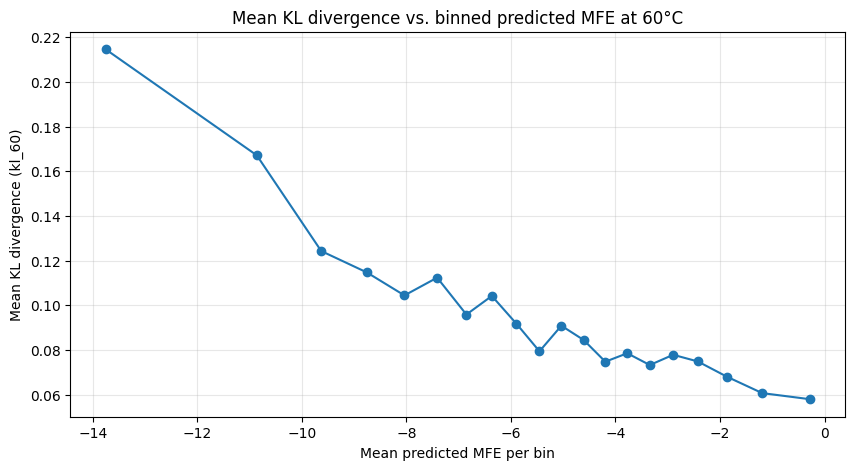

In [6]:
# Plot mean KL by predicted MFE bin
plt.figure(figsize=(10, 5))
plt.plot(summary["mean_mfe"], summary["mean_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("Mean KL divergence (kl_60)")
plt.title("Mean KL divergence vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

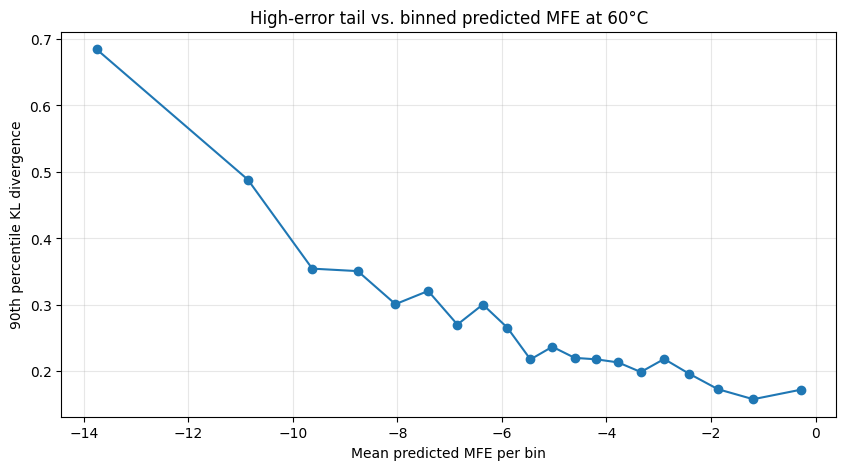

In [7]:
# Plot high-error tail: 90th percentile KL by MFE bin
plt.figure(figsize=(10, 5))
plt.plot(summary["mean_mfe"], summary["p90_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("90th percentile KL divergence")
plt.title("High-error tail vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

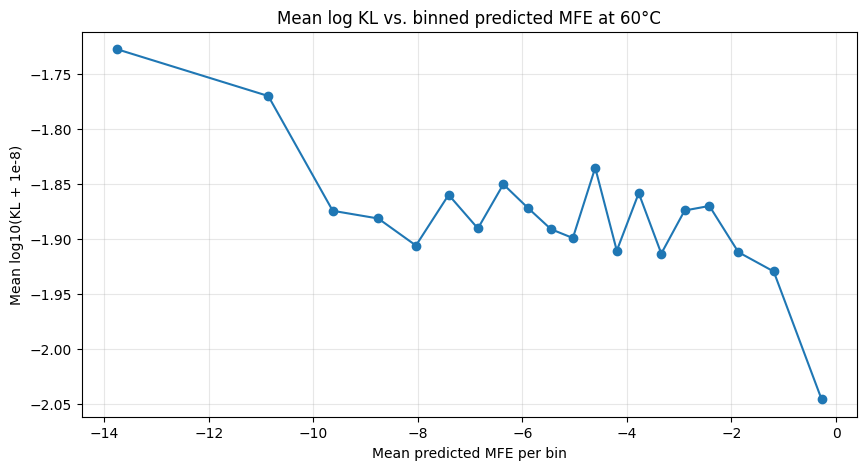

In [8]:
# Log-scale version, useful because KL is usually heavy-tailed
df["log_kl_60"] = np.log10(df["kl_60"] + 1e-8)

log_summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("log_kl_60", "size"),
        mean_log_kl=("log_kl_60", "mean"),
        median_log_kl=("log_kl_60", "median"),
        p90_log_kl=("log_kl_60", lambda x: x.quantile(0.90)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(log_summary["mean_mfe"], log_summary["mean_log_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("Mean log10(KL + 1e-8)")
plt.title("Mean log KL vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1400x500 with 0 Axes>

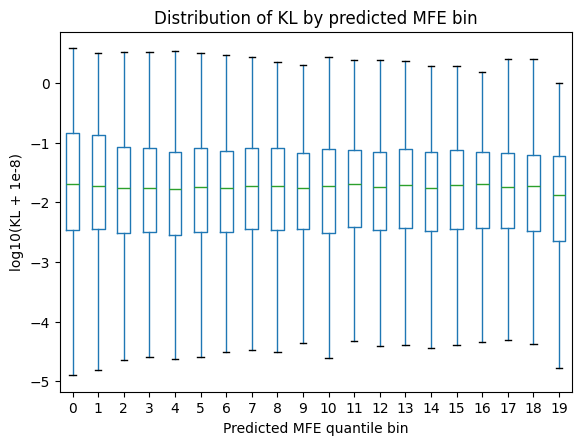

In [9]:
# Boxplot / distribution view across bins
plt.figure(figsize=(14, 5))
df.boxplot(
    column="log_kl_60",
    by="mfe_bin",
    grid=False,
    showfliers=False
)
plt.xlabel("Predicted MFE quantile bin")
plt.ylabel("log10(KL + 1e-8)")
plt.title("Distribution of KL by predicted MFE bin")
plt.suptitle("")
plt.show()

In [10]:
# Check whether lower MFE bins have larger KL
lowest_mfe_bin = summary.iloc[summary["mean_mfe"].idxmin()]
highest_mfe_bin = summary.iloc[summary["mean_mfe"].idxmax()]

print("Lowest MFE bin:")
print(lowest_mfe_bin)

print("\nHighest MFE bin:")
print(highest_mfe_bin)

ratio = lowest_mfe_bin["mean_kl"] / highest_mfe_bin["mean_kl"]
print(f"\nMean KL ratio, lowest MFE bin / highest MFE bin: {ratio:.3f}")

Lowest MFE bin:
mfe_bin_label    (-26.141000000000002, -11.71]
count                                     2410
mean_kl                               0.214612
median_kl                             0.020597
p90_kl                                0.684604
p95_kl                                1.229851
mean_mfe                            -13.755689
Name: 0, dtype: object

Highest MFE bin:
mfe_bin_label    (-0.78, 0.0]
count                    2378
mean_kl              0.057899
median_kl            0.013185
p90_kl               0.172444
p95_kl               0.280972
mean_mfe            -0.276905
Name: 19, dtype: object

Mean KL ratio, lowest MFE bin / highest MFE bin: 3.707


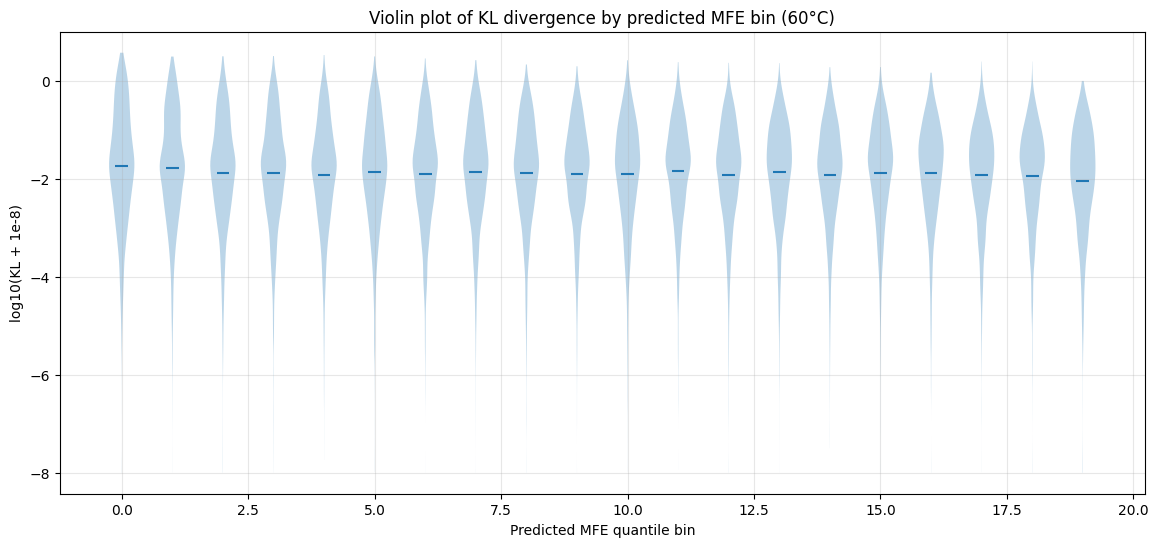

In [11]:
# Violin plot of KL distributions across predicted MFE bins

plt.figure(figsize=(14, 6))

# Build grouped data in bin order
grouped_data = [
    df[df["mfe_bin"] == b]["log_kl_60"].values
    for b in sorted(df["mfe_bin"].dropna().unique())
]

positions = sorted(df["mfe_bin"].dropna().unique())

plt.violinplot(
    grouped_data,
    positions=positions,
    showmeans=True,
    showmedians=False,
    showextrema=False
)

plt.xlabel("Predicted MFE quantile bin")
plt.ylabel("log10(KL + 1e-8)")
plt.title("Violin plot of KL divergence by predicted MFE bin (60°C)")

plt.grid(True, alpha=0.3)
plt.show()

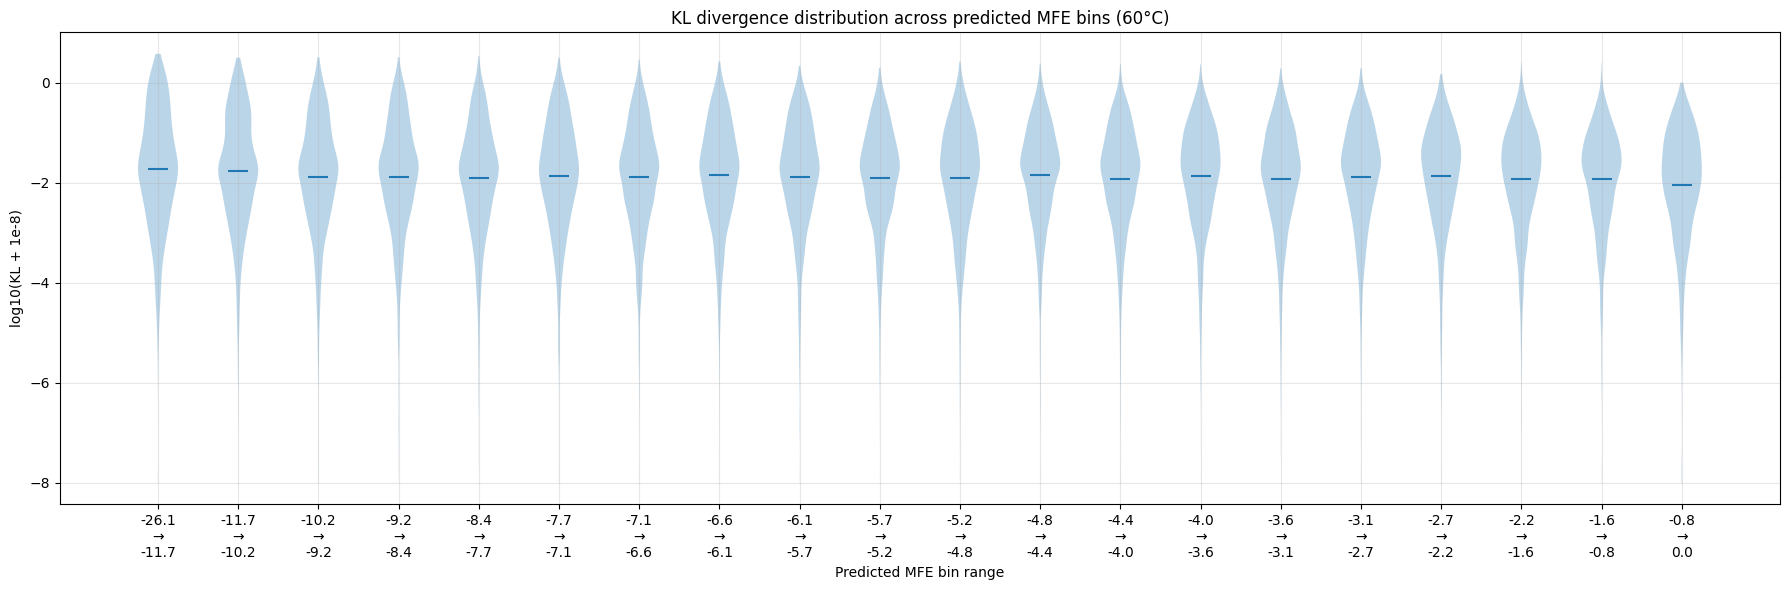

In [12]:
# Violin plot with actual MFE ranges as labels

plt.figure(figsize=(18, 6))

grouped_data = [
    df[df["mfe_bin"] == b]["log_kl_60"].values
    for b in sorted(df["mfe_bin"].dropna().unique())
]

positions = range(len(grouped_data))

plt.violinplot(
    grouped_data,
    positions=positions,
    showmeans=True,
    showmedians=False,
    showextrema=False
)

# Build readable labels
labels = [
    f"{interval.left:.1f}\n→\n{interval.right:.1f}"
    for interval in summary["mfe_bin_label"]
]

plt.xticks(positions, labels, rotation=0)

plt.xlabel("Predicted MFE bin range")
plt.ylabel("log10(KL + 1e-8)")
plt.title("KL divergence distribution across predicted MFE bins (60°C)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

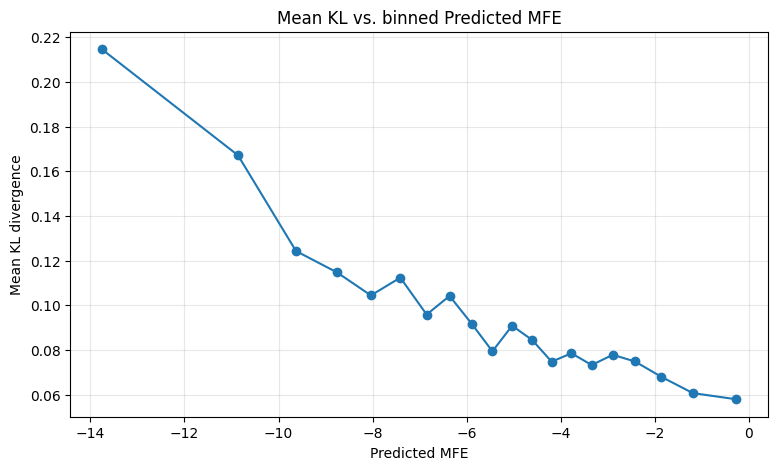

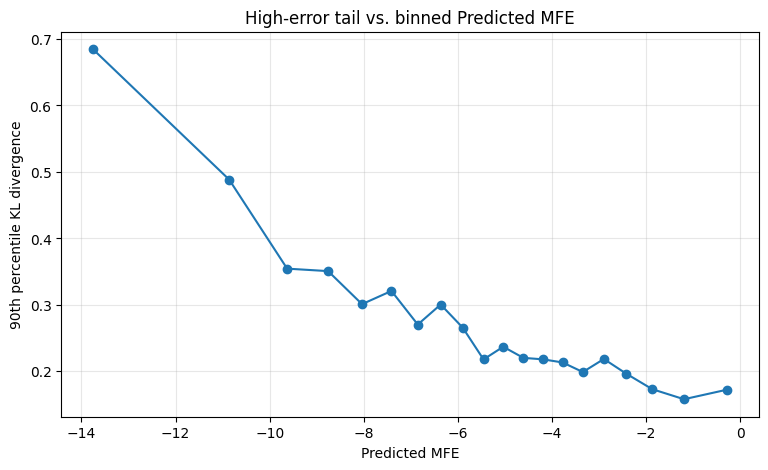

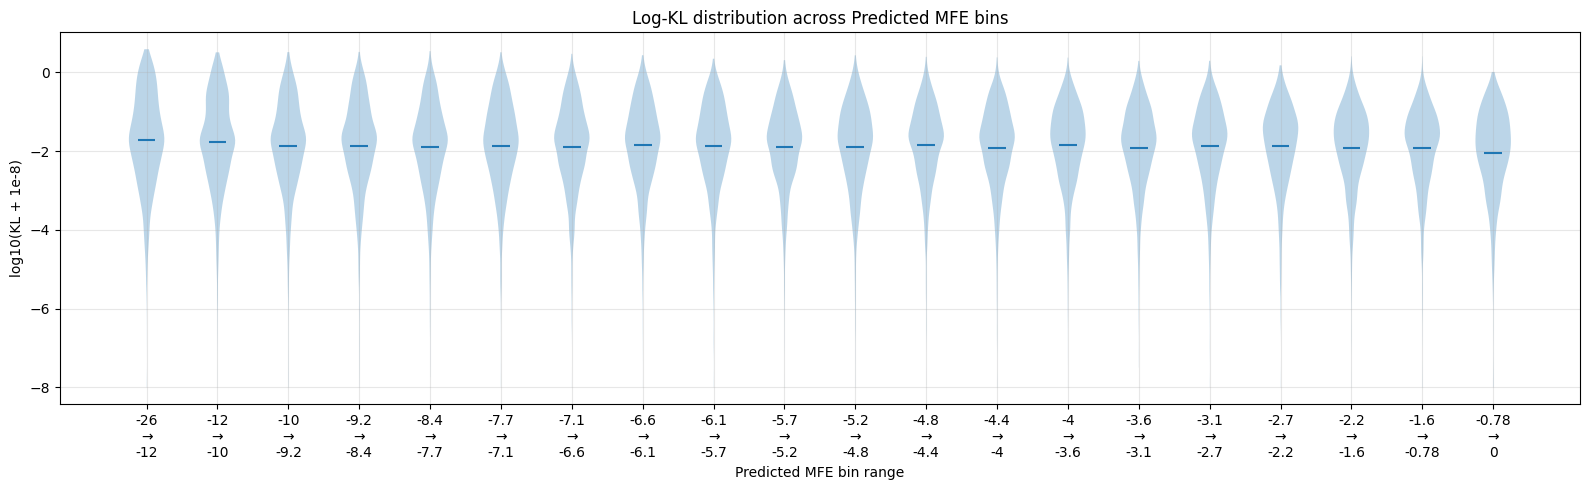

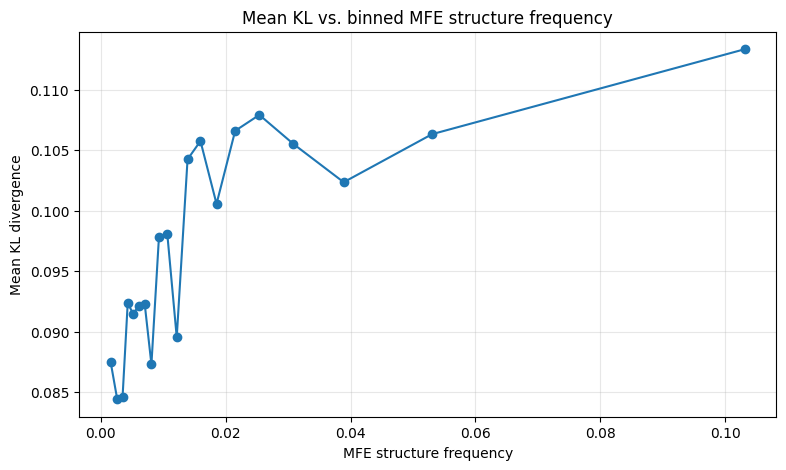

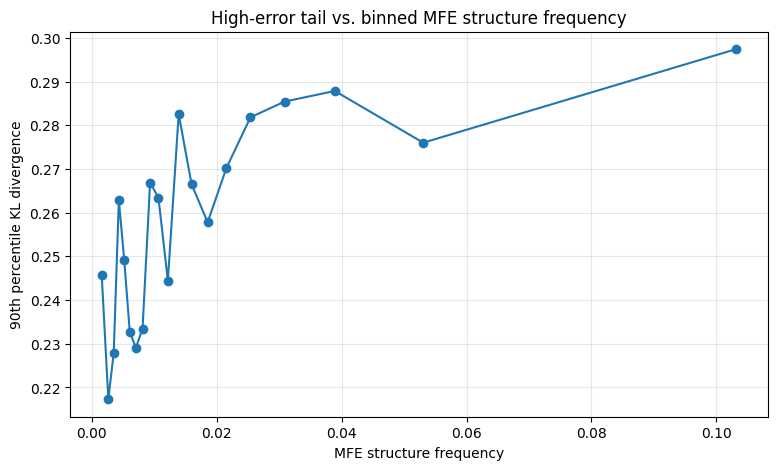

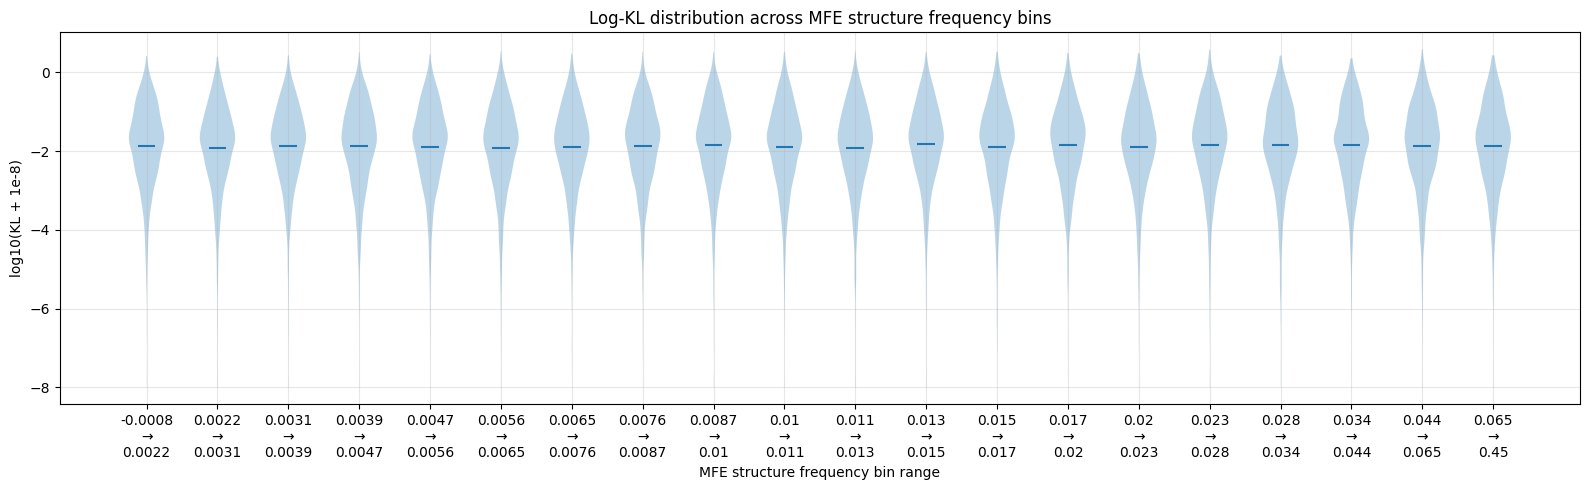

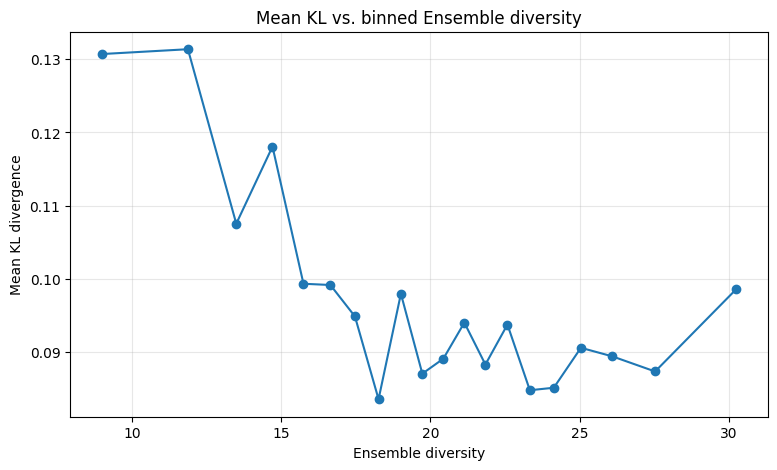

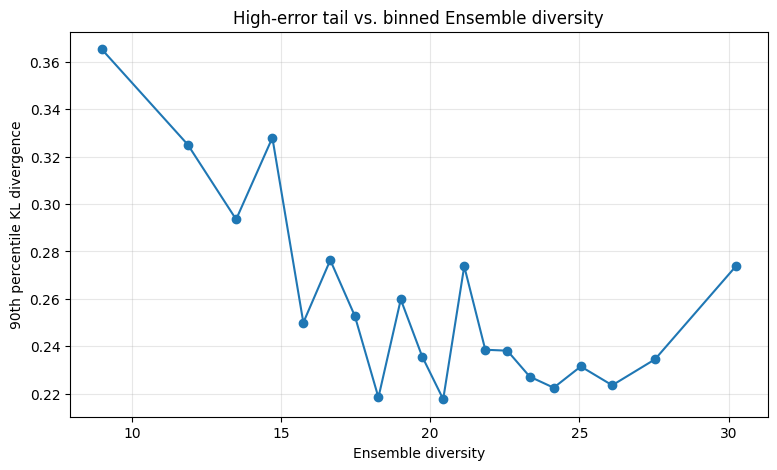

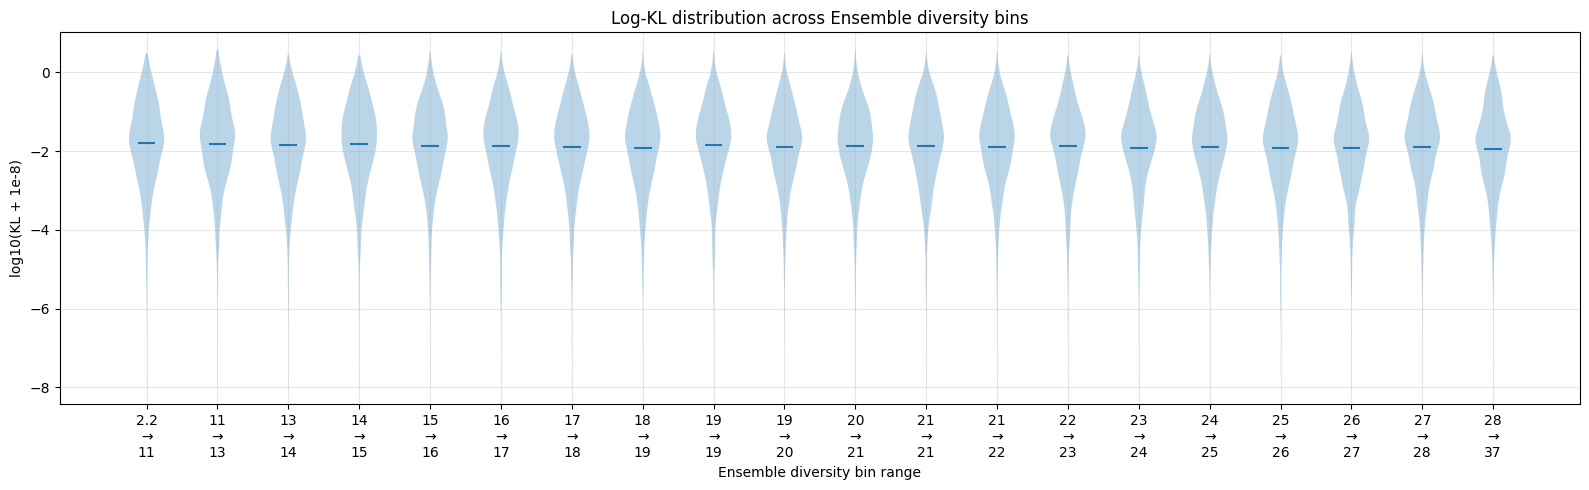

In [13]:
features = {
    "predicted_MFE": "Predicted MFE",
    "freq_MFE": "MFE structure frequency",
    "ensemble_diversity": "Ensemble diversity",
}

kl_col = "kl_60"
eps = 1e-8
n_bins = 20

df[kl_col] = pd.to_numeric(df[kl_col], errors="coerce")
df["log_kl"] = np.log10(df[kl_col] + eps)

for feature, feature_label in features.items():
    df[feature] = pd.to_numeric(df[feature], errors="coerce")
    
    tmp = df.dropna(subset=[feature, kl_col, "log_kl"]).copy()
    tmp["bin"] = pd.qcut(tmp[feature], q=n_bins, labels=False, duplicates="drop")
    tmp["bin_interval"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")
    
    summary = (
        tmp.groupby("bin_interval", observed=True)
        .agg(
            count=(kl_col, "size"),
            mean_feature=(feature, "mean"),
            mean_kl=(kl_col, "mean"),
            median_kl=(kl_col, "median"),
            p90_kl=(kl_col, lambda x: x.quantile(0.90)),
            mean_log_kl=("log_kl", "mean"),
        )
        .reset_index()
    )
    
    # Mean KL plot
    plt.figure(figsize=(9, 5))
    plt.plot(summary["mean_feature"], summary["mean_kl"], marker="o")
    plt.xlabel(feature_label)
    plt.ylabel("Mean KL divergence")
    plt.title(f"Mean KL vs. binned {feature_label}")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 90th percentile KL plot
    plt.figure(figsize=(9, 5))
    plt.plot(summary["mean_feature"], summary["p90_kl"], marker="o")
    plt.xlabel(feature_label)
    plt.ylabel("90th percentile KL divergence")
    plt.title(f"High-error tail vs. binned {feature_label}")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Violin plot
    bins = sorted(tmp["bin"].dropna().unique())
    grouped_data = [tmp[tmp["bin"] == b]["log_kl"].values for b in bins]
    
    labels = []
    for interval in summary["bin_interval"]:
        labels.append(f"{interval.left:.2g}\n→\n{interval.right:.2g}")
    
    plt.figure(figsize=(16, 5))
    plt.violinplot(
        grouped_data,
        positions=range(len(grouped_data)),
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    plt.xticks(range(len(labels)), labels, rotation=0)
    plt.xlabel(f"{feature_label} bin range")
    plt.ylabel("log10(KL + 1e-8)")
    plt.title(f"Log-KL distribution across {feature_label} bins")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()